Data for both visualizations taken from 
https://open.toronto.ca/dataset/oronto-island-ferry-ticket-counts/

Information answering questions in markdown files from course slides (01_materials/slides)


In [1]:
# Import libraries
import pandas as pd # reading and organizing data
import matplotlib.pyplot as plt #making plots

In [3]:
# Load the data from the CSV file
df = pd.read_csv("Toronto Island Ferry Ticket Counts.csv")

# Convert the Timestamp column from text to a date/time object as date is stored as text in CSV
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Take only the year from each date to group by year 
df["Year"] = df["Timestamp"].dt.year

# Group all rows by year and add up the ticket counts for each year
yearly = df.groupby("Year")[["Redemption Count", "Sales Count"]].sum().reset_index()

# Make year a regular column 
yearly = yearly.reset_index()

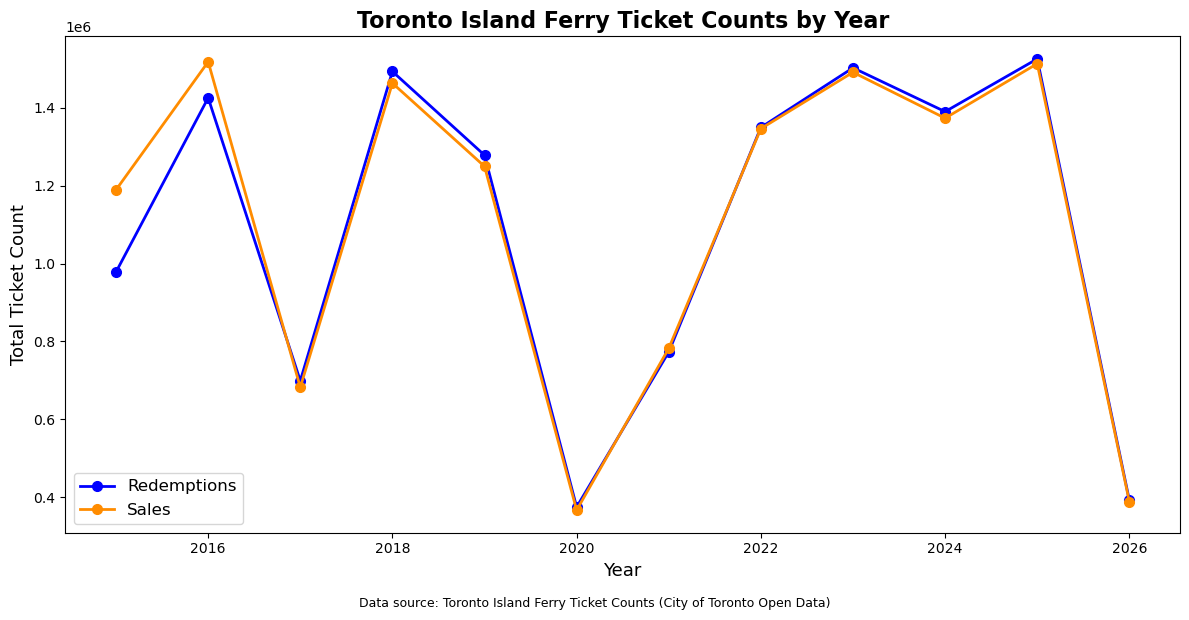

In [6]:
# Create a figure showing the yearly toitals for redemptions (tickets actually used to board the ferry) and sales (tickets purchased)

fig, ax = plt.subplots(figsize=(12, 6))

# Redemption Line 
ax.plot(
    yearly["Year"],            
    yearly["Redemption Count"],
    color="blue",         
    marker="o",                
    linewidth=2,               
    markersize=7,              
    label="Redemptions")   

# Sales Count
ax.plot(
    yearly["Year"],
    yearly["Sales Count"],
    color="darkorange",
    marker="o",               
    linewidth=2,
    markersize=7,
    label="Sales")

#Title 
ax.set_title("Toronto Island Ferry Ticket Counts by Year", fontsize=16, fontweight="bold")

# x and y axis 
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Total Ticket Count", fontsize=13)

# Legend 
ax.legend(fontsize=12)

# Data source label
fig.text(0.5, -0.02, "Data source: Toronto Island Ferry Ticket Counts (City of Toronto Open Data)",
         ha="center", fontsize=9, color="black")

# Tight layout 
plt.tight_layout()

# Save as PNG file
output_file = "ferry_ticket_counts.png"
plt.savefig(output_file, dpi=150, bbox_inches="tight")

# Display the chart on screen
plt.show()
